### Select folder

In [1]:
from PyQt6.QtWidgets import QApplication, QFileDialog
import sys

def select_folder_pyqt6():
    # Create application
    app = QApplication(sys.argv)

    # Open folder dialog
    folder_path = QFileDialog.getExistingDirectory(
        None,
        "Select a folder",
        ""
    )

    # Close QApplication
    app.exit()

    return folder_path

path = select_folder_pyqt6()
print(f"path: {path}")

path: X:/Anlagen/_lab31316-nlo/Inbox/experiment/202511_NLO_measurement_results/20251218_1730_BMF36-B0_d32_rotation


In [2]:
from shg_analysis import SHGDataAnalysis
from fitting_strategies.shoji1997 import Shoji1997Strategy
from crystaldatabase import CRYSTALS
from crystaldatabase import *

analysis = SHGDataAnalysis(path)
strategy = Shoji1997Strategy(analysis)
meta = analysis.meta
data = analysis.data

crystal = CRYSTALS[meta["material"]]()

### Modeling

In [3]:
fringe = strategy._maker_fringe()

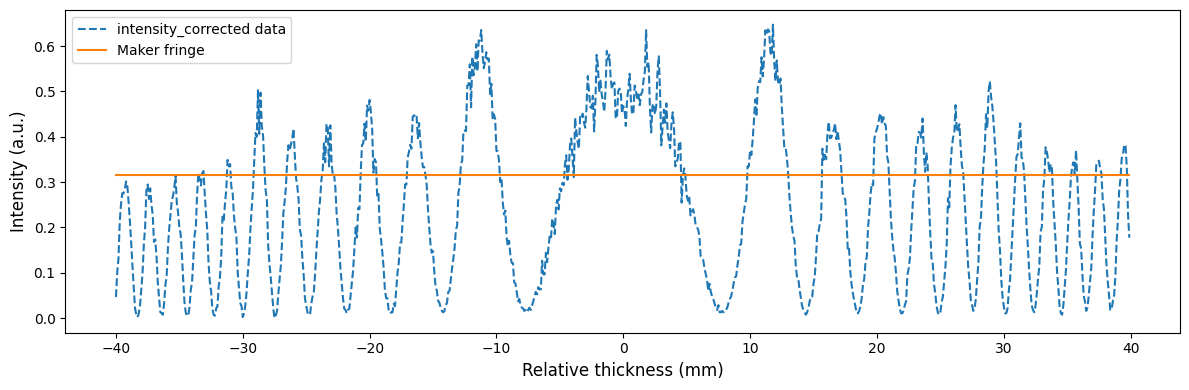

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = data["position"]
x = np.asarray(x)
intensity_corrected = data["intensity_corrected"]
intensity_corrected = np.asarray(intensity_corrected)

wedge_deg = meta["thickness_info"]["wedge_angle_deg"]
wedge = np.deg2rad(wedge_deg)

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(x, fringe, label='Maker fringe')
ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 10)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Check theoretical fringe without data

80


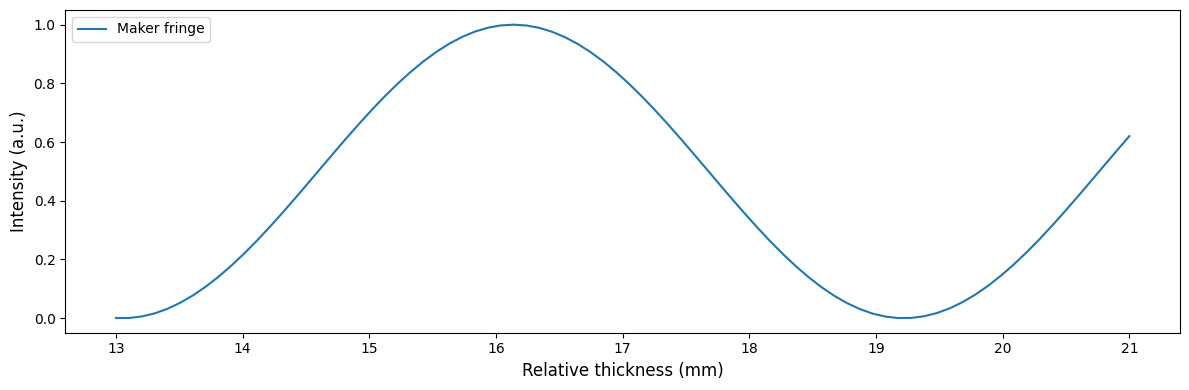

In [9]:
import pandas as pd
virtual_x = np.linspace(13, 21, 80)
virtual_data = pd.DataFrame()
virtual_data["position"] = virtual_x
print(np.size(virtual_data))

virtual_fringe = strategy._maker_fringe(override={"wedge_deg": 0.5, "data":virtual_data})

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(virtual_x, virtual_fringe, label='Maker fringe')
ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)
# ax.set_xlim(-20, 20)
# ax.set_ylim(0, 10)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Detect minima

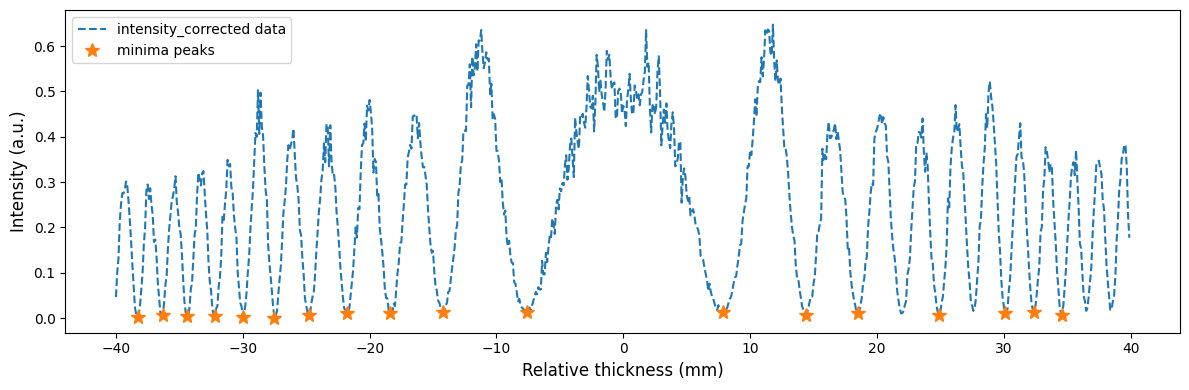

In [7]:
idx_min = strategy.detect_minima(x, intensity_corrected)
minima_x = x[idx_min]
minima_y = intensity_corrected[idx_min]

plt.rcParams['font.size'] = 10
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
ax.plot(minima_x, minima_y, "*", ms=10, label='minima peaks')

ax.set_xlabel('Relative thickness (mm)', fontsize=12)
ax.set_ylabel('Intensity (a.u.)', fontsize=12)

# ax.set_xlim(-20, 20)
# ax.set_ylim(-0.1, 3.2)

fig.tight_layout()
ax.legend(loc='upper left')
plt.show()

### Fit L

In [8]:
if meta["method"] == "rotation":
    pass
elif meta["method"] == "wedge":
    L_results, L_aux = strategy._fit_L()

    L_fit_mm = L_results["L_fit_mm"]
    L_fit_fringe = strategy._maker_fringe(override={"L": L_fit_mm})

    plt.rcParams['font.size'] = 10
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(x, intensity_corrected, label='intensity_corrected data', linestyle='--')
    ax.plot(x, L_fit_fringe, label='Thickness corrected fringe')
    ax.set_xlabel('Relative thickness (mm)', fontsize=12)
    ax.set_ylabel('Intensity (a.u.)', fontsize=12)
    # ax.set_xlim(-20, 20)
    # ax.set_ylim(0, 10)

    fig.tight_layout()
    ax.legend(loc='upper left')
    plt.show()